In [5]:
from jax.config import config
config.update("jax_enable_x64", True)
import json
import sys
import dLux
import collections
from observation import Dither

In [12]:
# import jax.numpy as np

# def instantiate_class(cls : object) -> object:
#     """
#     Constructs an 'empty' instance of the object using the class's _construct
#     method if it exists, then tries to construct it with an empty call of the 
#     class, otherwise returns the class itself.
    
#     Parameters
#     ----------
#     cls : object
#         The class to instantiate
    
#     Returns
#     -------
#     object : object
#         The instantiated class
#     """
#     return cls.__new__(cls)


def construct_class(modules_str : str) -> object:
    """
    Constructs an empty instance of some class from a string of the form
    'module.sub_module.class'. 

    Explicitly handled types: Nones, bool, int, float, str, complex, list, 
    tuple, dict, jax arrays, numpy arrays.

    Other types are imported and attempted to be instantiated.


    Parameters
    ----------
    modules_str : str
        The string of the form 'module.sub_module.class' to construct

    Returns
    -------
    object : object
        The instantiated class
    """
    # None case
    if modules_str == 'NoneType':
        return None

    # Regular python types
    elif modules_str in ['bool', 'int', 'float', 'str', 'complex', 'list', 
                         'tuple', 'dict']:
        return eval(f"{modules_str}()")

    # Array types
    elif modules_str == 'jaxlib.xla_extension.Array':
        import jax.numpy as jnp
        return jnp.array([])
    elif modules_str == 'numpy.ndarray':
        import numpy as onp
        return onp.array([])

    # Modules that existed in the global namespace - Search for it
    elif modules_str.startswith('__main__'):
        modules = modules_str.split('.')[1:]
        try:
            module = getattr(sys.modules['__main__'], modules[0])
            if len(modules) == 1:
                return module.__new__(module)
            else:
                for sub_module in modules:
                    module = getattr(module, sub_module)
                return module.__new__(module)
            # return module.__new__(module)

        except AttributeError:
            raise AttributeError(f"The module/class '{'.'.join(modules)}' "
                "originally existed in the global namespace, but does not "
                "exist in this script. It must be imported in order to be "
                "initialised.")
    
    # Finally attempt import of module
    else:
        from importlib import import_module as im
        modules = modules_str.split('.')

        if len(modules) == 1:
            raise ValueError(f"Unhandled case: {modules}")
        elif len(modules) == 2:
            cls = getattr(im(f'{modules[0]}'), modules[-1])
        else:
            sub_modules = '.'.join(modules[1:-1])
            cls = getattr(im(f'{modules[0]}.{sub_modules}'), modules[-1])
        # return instantiate_class(cls)
        return cls.__new__(cls)

In [13]:
import zodiax
import jax
import numpy
# from jax.typing import ArrayLike

def load_structure(structure : dict) -> object:
    """
    Load a structure from a dictionary to later be used in conjuction with
    `eqx.tree_deserialise_leaves()`.


    Custom leaf node desrialisation is handled by the `load_leaf` function.
    
    Parameters
    ----------
    structure : dict
        The structure to load.

    Returns
    -------
    obj : object
        The loaded structure.
    """
    # Construct the object
    obj = construct_class(structure['type'])

    # Container Node
    if structure['node_type'] == 'container': 
        
        # Iterarte over all parameters and update the object
        for key, value in structure['node'].items():
            obj = load_container(obj, key, value)
        return obj
    
    # Leaf Node
    else: 
        return load_leaf(obj, structure)


def load_container(obj : object, key : str, value : object) -> object:
    """
    Updates and return the object with the supplied key and value pair.

    Parameters
    ----------
    obj : object
        The object to update.
    key : str
        The key at which to update.
    value : object
        The corresponding value to update with.
    
    Returns
    -------
    obj : object
        The updated object.
    """
    # Recursively load the sub node
    sub_node = load_structure(value)

    # Object case
    if isinstance(obj, zodiax.Base):
        object.__setattr__(obj, key, sub_node)
    
    # Dict case
    else:
        obj[key] = sub_node
    
    return obj

def load_leaf(obj : object, structure : dict) -> object:
    """
    Returns the leaf value, handing the special cases of strings and arrays.
    Can be expanded to deal with mode complex cases.

    Parameters
    ----------
    obj : object
        The object to update.
    structure : dict
        The structure to load.

    Returns
    -------
    obj : object
        The updated object.
    """
    
    # String case
    if isinstance(obj, str):
        obj = structure['value']

    # Array case
    elif isinstance(obj, (jax.Array, numpy.ndarray)):
        import jax.numpy as np
        dtype = getattr(np, structure['dtype'])
        obj = np.zeros(structure['shape'], dtype=dtype)
    
    # All others
    else:
        pass
    
    return obj

import json
import equinox as eqx
import pickle as p
def deserialise(path):
    """
    Serialises the input object to the input path.

    Parameters
    ----------
    path : str
        The path to serialise the object to.
    obj : Any
        The object to serialise.
    """
    with open(path, 'rb') as f:
        structure = p.load(f)
        like = load_structure(structure)
        obj = eqx.tree_deserialise_leaves(f, like)
    return obj

obj = deserialise('tel.zdx')

In [14]:
obj

Instrument(
  optics=Optics(
    layers={
      'CreateWavefront':
      CreateWavefront(
        name='CreateWavefront',
        npixels=256,
        diameter=f64[],
        wavefront_type='Angular'
      ),
      'CircularAperture':
      StaticAperture(name='CircularAperture', aperture=f64[256,256]),
      'NormaliseWavefront':
      NormaliseWavefront(name='NormaliseWavefront'),
      'AngularMFT':
      AngularMFT(
        name='AngularMFT',
        inverse=False,
        npixels_out=32,
        pixel_scale_out=f64[],
        shift=f64[2],
        pixel_shift=False
      )
    }
  ),
  scene=Scene(
    sources={
      'PointSource':
      PointSource(
        position=f64[2],
        flux=f64[],
        spectrum=ArraySpectrum(
          name='ArraySpectrum',
          wavelengths=f64[1],
          weights=f64[1]
        ),
        name='PointSource'
      )
    }
  ),
  detector=None,
  filter=None,
  observation=Dither(name='Observation', dithers=f64[4,2])
)

In [15]:
# structure = json.load(open('structure.json', 'r'))
# out = load_structure(structure)

In [16]:
# import equinox as eqx
# tel = eqx.tree_deserialise_leaves("tel.eqx", out)

In [17]:
# psfs = tel.observe()
psfs = obj.observe()

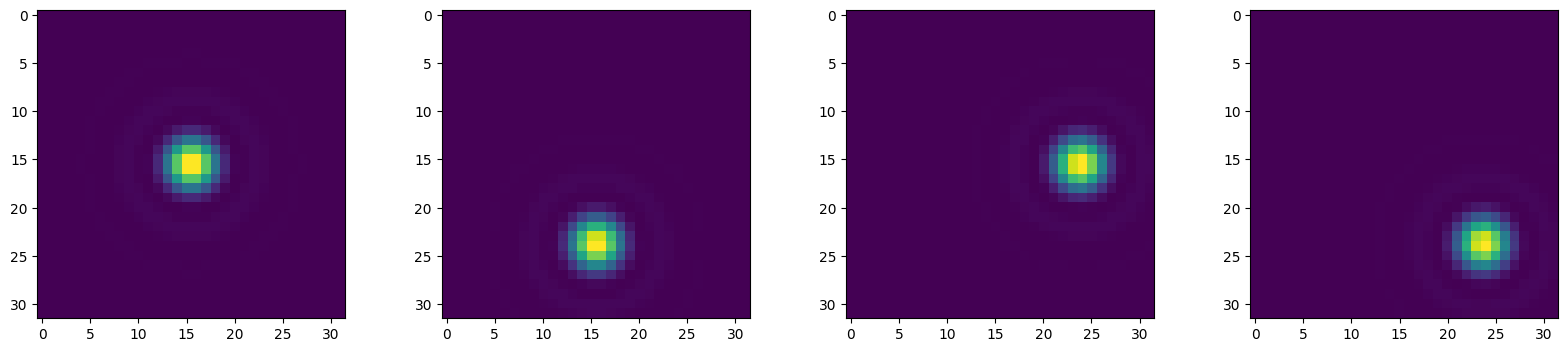

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
# psfs = tel.observe()
psfs = obj.observe()
for i in range(len(psfs)):
    plt.subplot(1, 4, i+1)
    plt.imshow(psfs[i])
plt.show()